In [1]:
# Example loading and plotting lidar data of Hybrid Dune Campaign

import numpy as np 
import xarray as xr
import os   
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

from netCDF4 import Dataset
import warnings

import sys
sys.path.append('../functions')
from convert_lidar_coordinates_ds_single import convert_lidar_coordinates_ds


In [1]:
1+2

3

In [2]:
def filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=None, profile_isel=None):
    # Example loading and filtering lidar data of Hybrid Dune Campaign

    # Define frame angles to be skipped
    # Initialize the array: shape (3, 2, 4, 3) for 3 skip_regions × 2 limits (start_stop) × 4 lidars × 3 storms
    hoek_frame_skip = np.zeros((3, 2, 4, 3))
    # S1
    hoek_frame_skip[:, :, 0, 0] = [[-17.4, -14.9], [-13.8, -10.9], [-2.75, 0]]   # storm 1
    hoek_frame_skip[:, :, 0, 1] = [[-16.9, -13.9], [-13.3, -9.9], [-2.25, 0.5]]  # storm 2
    hoek_frame_skip[:, :, 0, 2] = [[-17.4, -14.4], [-13.8, -10.9], [-2.75, 0]]   # storm 3

    # S2
    hoek_frame_skip[:, :, 1, 0] = [[-21.2, -18.2], [-14.3, -11.3], [-2.3, 0.7]]
    hoek_frame_skip[:, :, 1, 1] = [[-20.2, -17.7], [-13.8, -10.8], [-1.3, 1.7]]
    hoek_frame_skip[:, :, 1, 2] = [[-21.2, -18.2], [-14.3, -11.8], [-2.3, 0.7]]

    # S3
    hoek_frame_skip[:, :, 2, 0] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 1] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 2] = [[-17.5, -14.5], [-12.5, -10.0], [0.5, 4.0]]

    # S4
    hoek_frame_skip[:, :, 3, 0] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 1] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 2] = [[-19.75, -16.75], [-11.75, -8.75], [-3.25, -0.25]]

        # # determine limits to load data from: which vertical angles to select. Between -90° and 105°
        # ds = xr.open_dataset(nc_in).isel(profile_number=0, t=0, echos=0)   # select specific time range: t0 until t_end

        # # # find obs_number with -90° < beam_angle < 105°
        # i_obs_start = np.where(ds.beam_angle.values > -90)[0][0]
        # i_obs_end = np.where(ds.beam_angle.values < 93)[0][-1]
        # print(i_obs_end)

    i_obs_start = 360  # set manually, always the same if looking for the same angles.Here: straight under lidar
    i_obs_end = 545 # for 93deg

    # load data with these obs_number limits
    if (t_sel is  None) and (profile_isel is None):
        ds = xr.open_dataset(nc_in).isel(obs_number=slice(i_obs_start, i_obs_end))                                            # select specific angles
    elif t_sel is None:
        ds = xr.open_dataset(nc_in).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))               # select specific angles and profile
    elif profile_isel is None:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(obs_number=slice(i_obs_start, i_obs_end))                               # select specific angles and time range
    else:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))  # select specific angles, profile and time range

    # Filter out the frame -----------------------------------------------------------------------
    # Filter out the frame by replacing values in ds.beam_angle with NaN where the laser sees the frame. Then use filtered beam angles for coordianate conversion.

    # Select the slice for given n_lidar and n_storm (Python: 0-based)
    # Example: n_lidar = 1, n_storm = 2 (MATLAB) -> Python: 0, 1
    hoek_frame_skip_slice = hoek_frame_skip[:, :, n_lidar-1, n_storm-1] 

    # Filter frame: loop, for every row in hoek_frame_skip_slice, make angles nan where angles>value_col_1 and angles<value_col_2
    angles = ds.beam_angle.values

    for row in hoek_frame_skip_slice:
        angles[(angles > row[0]) & (angles < row[1])] = np.nan

    ds.beam_angle.values = angles   

    # Convert to local coordinates
    ds = convert_lidar_coordinates_ds(ds, 'local', max_echos=True, keep_I=False, keep_r=True, keep_y=False) # skip intensity, take max distance of echos

    # Define skip area (to remove points below x=6m and above z=-1m)
    x_skip_area = 6.5   # delete every point that is less than 6 m landward of lidar, and (simultaneously) less than 1 m below the lidar
    z_skip_area = -1
    x_min = ds.x_i_local.values + x_skip_area
    z_max = ds.z_i.values + z_skip_area

    # make x, y, z values nan where (x < x_skip_area) & (z > z_skip_area)
    mask_keep = (ds.x.values > x_min) | (ds.z.values < z_max) # keep where either condition is met. So remove where <x_lmin and >z_max
    ds['x'] = ds.x.where(mask_keep)
    #ds['y'] = ds.y.where(mask_keep)
    ds['z'] = ds.z.where(mask_keep)
    ds['radius_lidar'] = ds.radius_lidar.where(mask_keep)

    return ds


In [90]:
# LOAD POINTCLOUD AND FILTER DATA, VERSION NCK THEMEDAY: MOVMAX OVER 10 MINUTES
# INPUT PARAMETERS ------------------------------------------------------------------------------------------------
n_lidar = 2  # set as needed (1-based, like MATLAB)

for n_storm in [1]: #[1, 2, 3]:
#n_storm = 1 # set as needed (1-based, like MATLAB)

    nc_in = fr"C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Lidar\data\S{n_lidar} Lidar, storm{n_storm}.nc"
    if n_storm == 1:
        t1 = pd.Timestamp('19-12-2024 00:00') # was 2:00
        t2 = pd.Timestamp('20-12-2024 00:09') # was 19dec 22:00
        t1 = pd.Timestamp('18-12-2024 14:20')
        t2 = pd.Timestamp('18-12-2024 15:20')
    elif n_storm == 2:
        t1 = pd.Timestamp('22-12-2024 04:00')
        t2 = pd.Timestamp('22-12-2024 23:09')
    elif n_storm == 3:
        t1 = np.datetime64('2025-01-01T12:00')
        t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
    else:
        raise ValueError('n_storm must be 1, 2, or 3')

    # LOAD AND FILTER POINTCLOUD ----------------------------------------------------------------------------------------
    #ds.close()
    ds = filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=slice(t1, t2), profile_isel=2) # Filter out frame and high waves (points less than 1 m below lidar and offshore of dune toe)
    ds = ds.drop_vars(['x','z'])

    # EXTRACT DUNE PROFILES FROM POINTCLOUDS ----------------------------------------------------------------------------
    # take moving max radius over X minutes, ignore NaNs
    dt_minutes = 10
    window_length = np.int16(dt_minutes * 60 * ds.sf.values) # 5 minutes * 60 seconds * 4 Hz
    ds['radius_lidar'] = ds.radius_lidar.rolling(t=window_length, center=True, min_periods=1).max()   # min_periods=1: 1 non-nan value is enough. So A) ignore nans and b) ignore window edges

    # Select one point cloud per window: For each instant in time_vector, select the first t >= time_vector[i]
    #time_vector = pd.date_range(start=t1, end=t2, freq=f'{dt_minutes}min')
    time_vector = pd.date_range(start=t1, end=t2, freq='20min')

    t_vals = pd.to_datetime(ds.t.values)
    selected_indices = []
    for t_ref in time_vector:
        idx = np.searchsorted(t_vals, t_ref, side='left')
        if idx < len(t_vals):
            selected_indices.append(idx)

    ds_plot = ds.isel(t=selected_indices)

    # Remove outliers: make r nan where the difference between consecutive r values over dim obs_number is larger than 0.5 m
    mask_full = xr.DataArray(np.ones_like(ds_plot.radius_lidar, dtype=bool), dims=ds_plot.radius_lidar.dims, coords=ds_plot.radius_lidar.coords)  # pre-define mask: size of ds.radius_lidar, true everywhere
    r_diff = ds_plot.radius_lidar.diff(dim='obs_number')                     # Calculate the difference between consecutive values
    mask = np.abs(r_diff) <= 0.5                                        # Create a mask: True where the difference is <= 0.5, False where it's an outlier
    mask_full.values[1:,:] = mask.values                                # Combine the mask
    ds_plot['radius_lidar'] = ds_plot.radius_lidar.where(mask_full)               # Apply the mask: set outliers to NaN

    # Recalculate x and z, based on the max r per window
    ds_plot = convert_lidar_coordinates_ds(ds_plot, 'local', max_echos=False, keep_I=False, keep_r=False, keep_y=False) # skip intensity, take max distance of echos

    if n_storm == 1:
        ds1a=ds_plot.copy()
    elif n_storm == 2:
        ds2a=ds_plot.copy()
    elif n_storm == 3:
        ds3a=ds_plot.copy()

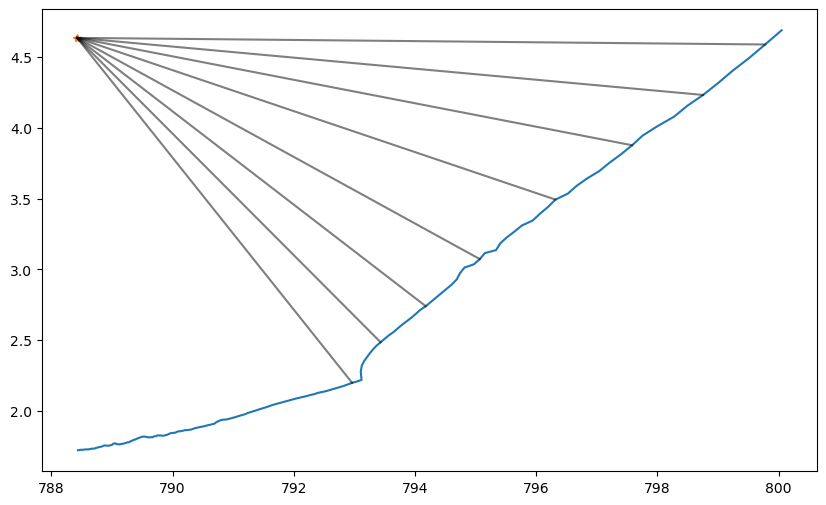

In [95]:
#ds_sel = ds_plot.sel(t=slice('2024-12-19T16:00', '2024-12-19T16:19')) # select specific time range for plotting
ds_sel = ds_plot.sel(t=slice('2024-12-18T14:40', '2024-12-18T14:59')) # select specific time range for plotting

ds_sel

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ds_sel.x.values, ds_sel.z.values)
ax.plot(ds_sel.x_i_local.values, ds_sel.z_i.values,'*')

# plot line from (x_i_local, z_i) to (x, z) for every 10th value in obs_number
i_all = [10, 40, 65, 90, 110, 125, 135, 145, 155, 165, 172, 180]
i_all = [125, 135, 145, 155, 165, 172, 177, 181]

for i in i_all:
    x = [ds_sel.x_i_local.values, ds_sel.x.values[i,0]]
    z = [ds_sel.z_i.values, ds_sel.z.values[i,0]]
    ax.plot(x, z, 'k-', alpha=0.5)

In [ ]:
# LOAD POINTCLOUD AND FILTER DATA, V2: r90%=r99%
# INPUT PARAMETERS ------------------------------------------------------------------------------------------------
n_lidar = 2  # set as needed (1-based, like MATLAB)

for n_storm in [1]: #[1, 2, 3]:
#n_storm = 1 # set as needed (1-based, like MATLAB)

    nc_in = fr"C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Lidar\data\S{n_lidar} Lidar, storm{n_storm}.nc"
    if n_storm == 1:
        t1 = pd.Timestamp('19-12-2024 00:00') # was 2:00
        t2 = pd.Timestamp('20-12-2024 00:09') # was 19dec 22:00
    elif n_storm == 2:
        t1 = pd.Timestamp('22-12-2024 04:00')
        t2 = pd.Timestamp('22-12-2024 23:09')
    elif n_storm == 3:
        t1 = np.datetime64('2025-01-01T12:00')
        t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
    else:
        raise ValueError('n_storm must be 1, 2, or 3')

    # LOAD AND FILTER POINTCLOUD ----------------------------------------------------------------------------------------
    #ds.close()
    ds = filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=slice(t1, t2), profile_isel=2) # Filter out frame and high waves (points less than 1 m below lidar and offshore of dune toe)
    ds = ds.drop_vars(['x','z'])


In [ ]:
# 1. Select the percentiles you want
percentiles = np.arange(50, 100) 
#percentiles = [50, 90, 99] #

# 1. Create minute labels for each time step
minute_labels = pd.to_datetime(ds.t.values).floor('min') # floor by minute, so all time steps within the same minute get the same label

# 2. Assign as a new coordinate
ds = ds.assign_coords(minute=('t', minute_labels))

# Extract r, with new minute labels
r = ds.radius_lidar

# 4. Use groupby on 'minute' and apply nanpercentile along the 't' axis for each obs_number
# Apply groupby and nanpercentile
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN slice encountered")
    r_percentiles = r.groupby('minute').apply(
        lambda x: xr.DataArray(
            np.nanpercentile(x.values, q=percentiles, axis=1),  # shape: (len(q), obs_number)
            dims=['q', 'obs_number'],
            coords={'q': percentiles, 'obs_number': x.obs_number}
        )
    )

# Now r_percentiles has dims (minute, q, obs_number)
# If you want (minute, obs_number, q), you can transpose:
r_percentiles = r_percentiles.transpose('obs_number', 'minute', 'q')

# Example: r_percentiles.sel(q=95) gives the 95th percentile profile per minute

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_21580\3277281493.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


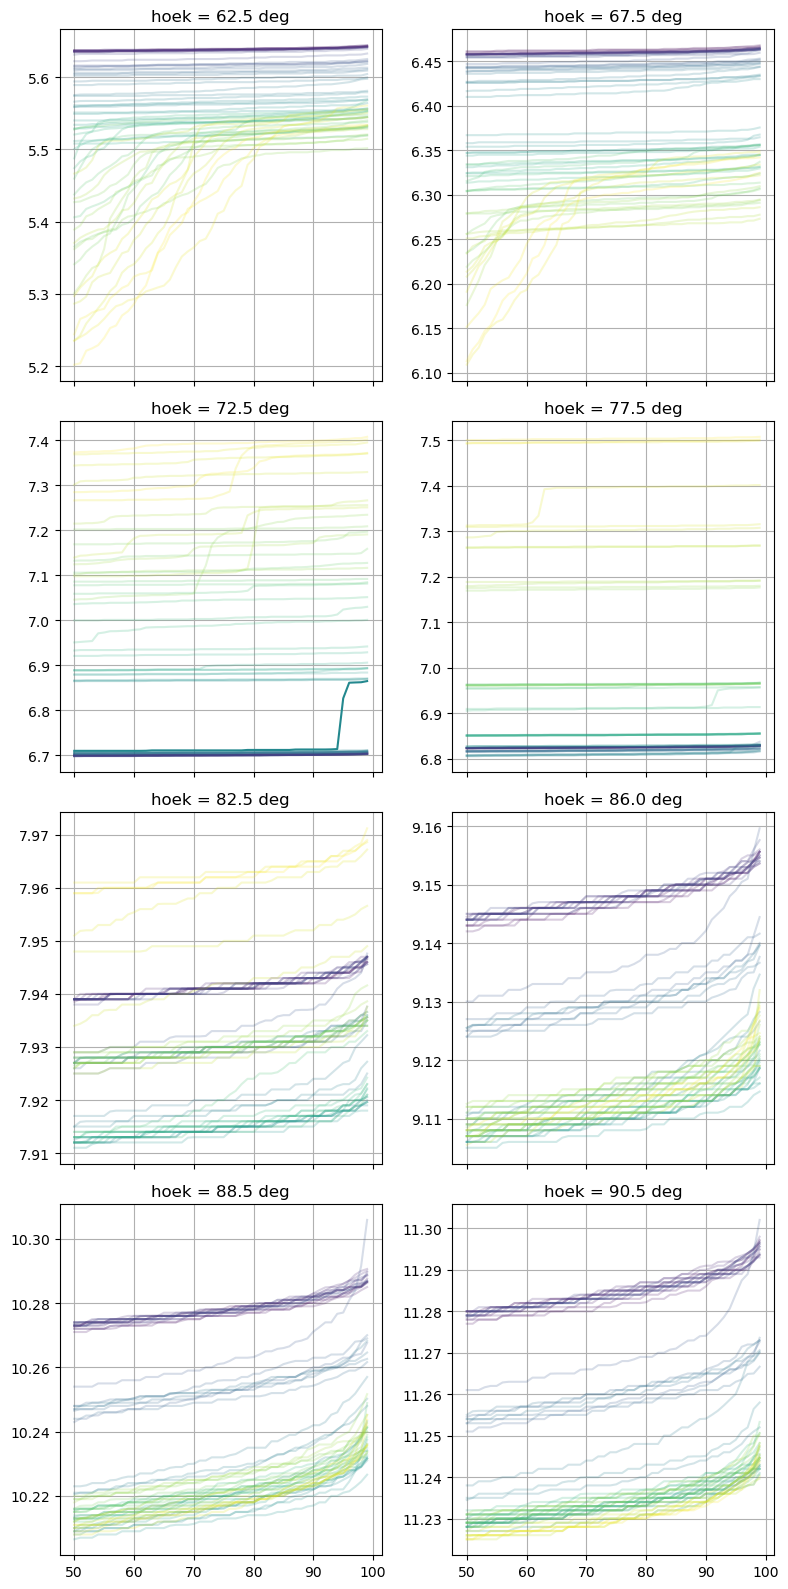

In [125]:
# Make a plot of r_percentiles: percentile (x) vs radius (y), with one line per minute, and color by minute
t1 = pd.Timestamp('19-12-2024 16:00') 
t2 = pd.Timestamp('19-12-2024 17:00') 
r_percentiles_plot = r_percentiles.sel(minute=slice(t1, t2))
i_all =  [10, 40, 65, 90, 110, 125, 135, 145, 155, 165, 172, 180]
i_all = [125, 135, 145, 155, 165, 172, 177, 181]


# Set colors for plotting
minutes = r_percentiles_plot.minute.values
# Convert to pandas Timestamps for easier handling
minutes_pd = pd.to_datetime(minutes)
# Use the integer index of each minute for coloring
minute_numbers = (minutes_pd - minutes_pd[0]).total_seconds() / 60  # minutes since start

norm = mcolors.Normalize(vmin=minute_numbers.min(), vmax=minute_numbers.max())
cmap = cm.get_cmap('viridis')

# make plot
fig, axs = plt.subplots(4, 2, figsize=(8, 16), sharex=True)
axs = axs.flatten()

for idx, i_0 in enumerate(i_all):
    ax = axs[idx]
    for m_idx, minute in enumerate(minutes):
        color = cmap(norm(minute_numbers[m_idx]))
        r_percentiles_minute = r_percentiles_plot.sel(obs_number=i_0, minute=minute)
        #ax.plot(r_percentiles_minute.q, r_percentiles_minute.values, alpha=0.2, color=color)
        
        # Get the 99th and 90th percentile values for this minute and obs_number
        r_99 = r_percentiles_minute.sel(q=99).item()
        r_90 = r_percentiles_minute.sel(q=90).item()
        alpha_val = 0.2 if (r_99 - r_90) < 0.05 else 1.0

        ax.plot(r_percentiles_minute.q, r_percentiles_minute.values, alpha=alpha_val, color=color)
    ax.grid()
    ax.set_title(f"hoek = {i_0/2:.1f} deg")

# # Add a colorbar for time
# sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)
# cbar.set_label('Minutes since start')

plt.tight_layout()
plt.show()

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_21580\1280876201.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


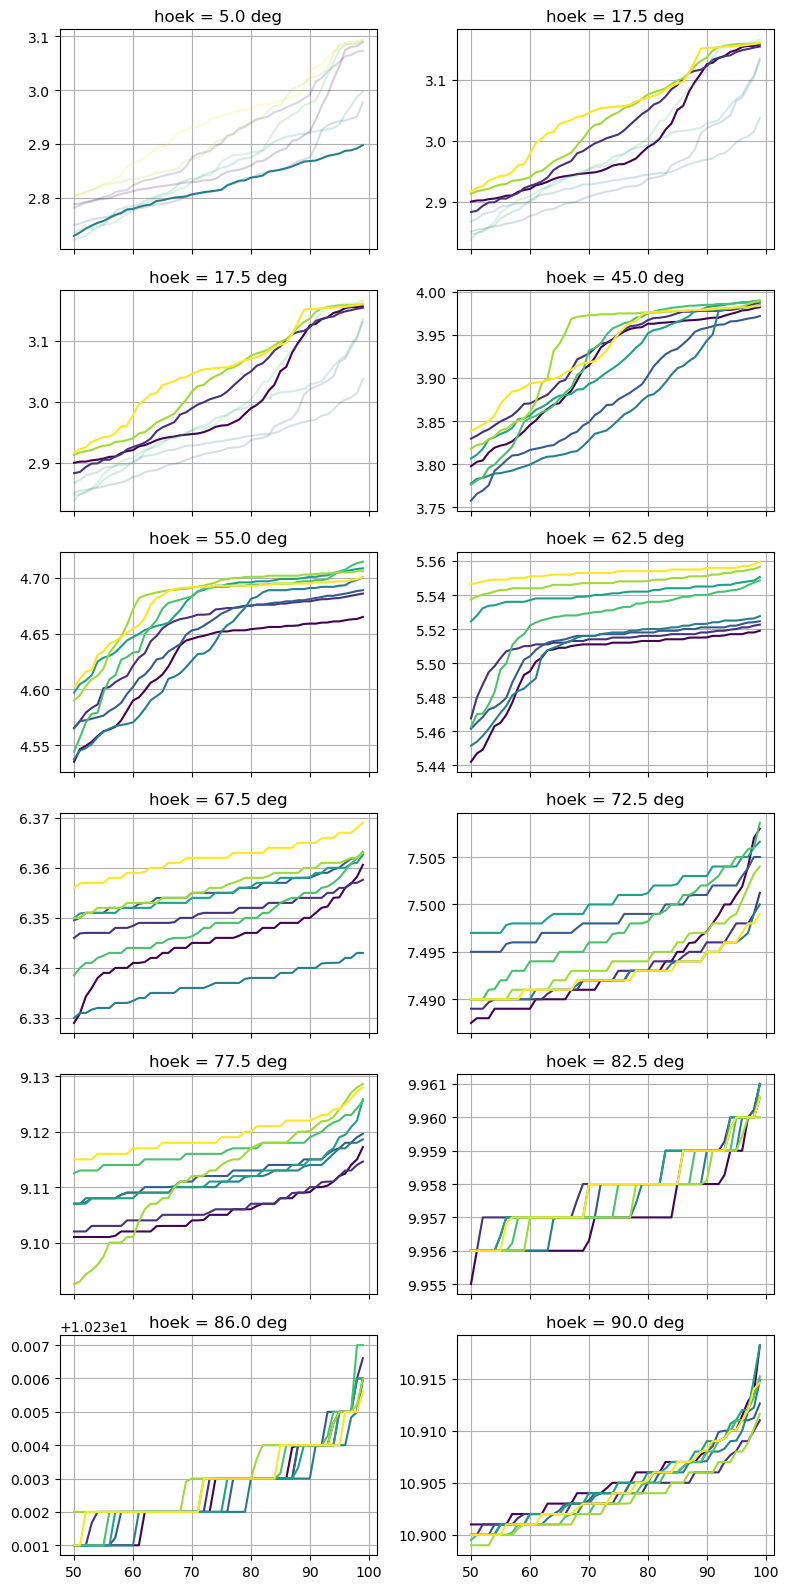

In [141]:
# Make a plot of r_percentiles: percentile (x) vs radius (y), with one line per minute, and color by minute
t1 = pd.Timestamp('19-12-2024 19:49') 
t2 = pd.Timestamp('19-12-2024 19:56') 
r_percentiles_plot = r_percentiles.sel(minute=slice(t1, t2))
i_all = [125, 135, 145, 155, 165, 172, 177, 181]
i_all =  [10, 35, 35, 90, 110, 125, 135, 145, 155, 165, 172, 180]

# Set colors for plotting
minutes = r_percentiles_plot.minute.values
# Convert to pandas Timestamps for easier handling
minutes_pd = pd.to_datetime(minutes)
# Use the integer index of each minute for coloring
minute_numbers = (minutes_pd - minutes_pd[0]).total_seconds() / 60  # minutes since start

norm = mcolors.Normalize(vmin=minute_numbers.min(), vmax=minute_numbers.max())
cmap = cm.get_cmap('viridis')

# make plot
fig, axs = plt.subplots(6, 2, figsize=(8, 16), sharex=True)
axs = axs.flatten()

for idx, i_0 in enumerate(i_all):
    ax = axs[idx]
    for m_idx, minute in enumerate(minutes):
        color = cmap(norm(minute_numbers[m_idx]))
        r_percentiles_minute = r_percentiles_plot.sel(obs_number=i_0, minute=minute)
        #ax.plot(r_percentiles_minute.q, r_percentiles_minute.values, alpha=0.5, color=color)

        # Get the 99th and 90th percentile values for this minute and obs_number
        r_99 = r_percentiles_minute.sel(q=99).item()
        r_90 = r_percentiles_minute.sel(q=90).item()
        r_75 = r_percentiles_minute.sel(q=75).item()
        alpha_val = 1.0 if (r_99 - r_90) < 0.05 else 0.2

        ax.plot(r_percentiles_minute.q, r_percentiles_minute.values, alpha=alpha_val, color=color)
    ax.grid()
    ax.set_title(f"hoek = {i_0/2:.1f} deg")

plt.tight_layout()
plt.show()

In [143]:
# 1) Extract percentile profiles ------------------------------
percentiles = [50, 90, 99]

# Create minute labels for each time step
minute_labels = pd.to_datetime(ds.t.values).floor('min') # floor by minute, so all time steps within the same minute get the same label

# Assign as a new coordinate
ds = ds.assign_coords(minute=('t', minute_labels))

# Extract r, with new minute labels
r = ds.radius_lidar

def nanpercentile_q(a, q):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN slice encountered")
        return np.nanpercentile(a, q, axis=-1)

r_percentiles = xr.apply_ufunc(
    nanpercentile_q,
    r.groupby('minute'),
    percentiles,
    input_core_dims=[['t'], ['q']],
    output_core_dims=[['q']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float],
    keep_attrs=True
)
r_percentiles = r_percentiles.transpose('obs_number', 'minute', 'q')
r_percentiles = r_percentiles.assign_coords(q=percentiles)

In [146]:
# 2) Outlier filtering------------------------------
r_50 = r_percentiles.sel(q=50)
r_90 = r_percentiles.sel(q=90)
r_99 = r_percentiles.sel(q=99)

cond1 = (r_99 - r_90) < 0.05  # if close, then both are dry. Use 90%
cond2 = (r_90 - r_50) < 0.05  # if 99% has a larger difference but 50% is close, than probably all dry, but slumping between 90% and 99%

r_filtered = xr.full_like(r_90, np.nan)
r_filtered = r_filtered.where(False)  # all nan
r_filtered = r_filtered.where(~(cond1 | cond2), r_90)

# 3) Temporal interpolation ----------------------------
# Interpolate temporally (along 'minute'), for given obs_number, if Δr<5cm between previous and next valid value.
r_temp_interp = r_filtered.interpolate_na(dim="minute", method="linear", use_coordinate=False) # fill nan gaps by linear interpolation

# Get previous and next valid values for each obs_number (temporal direction)
r_prev = r_filtered.ffill(dim="minute")
r_next = r_filtered.bfill(dim="minute")

# Mask: where the difference between previous and next is too large, set to nan
mask_temp = np.abs(r_prev - r_next) > 0.05
r_temp_filtered = r_temp_interp.where(~mask_temp)

# 4) Spatial interpolation ----------------------------
# Interpolate spatially (along 'obs_number'), for given minute, if Δr<5cm
r_spat_interp = r_temp_filtered.interpolate_na(dim="obs_number", method="linear", use_coordinate=False)

# Get previous and next valid values for each minute (spatial direction)
r_prev_spat = r_temp_filtered.ffill(dim="obs_number")
r_next_spat = r_temp_filtered.bfill(dim="obs_number")

# Mask: where the difference between previous and next is too large, set to nan
mask_spat = np.abs(r_prev_spat - r_next_spat) > 0.05
r_final = r_spat_interp.where(~mask_spat)

# r_final = r_filtered # Comment to see result without interpolation
# Define a new ds_profiles: a copy of ds, without the coordinate t, and with r_final as radius_lidar
ds_profiles = ds.isel(t=0, drop=True)  # drops t dimension and its coordinate from ds
ds_profiles['radius_lidar'] = r_final  # Assign r_final as the new radius_lidar

ds_profiles = convert_lidar_coordinates_ds(ds_profiles, 'local', max_echos=False, keep_I=False, keep_r=True, keep_y=False) # skip intensity, take max distance of echos

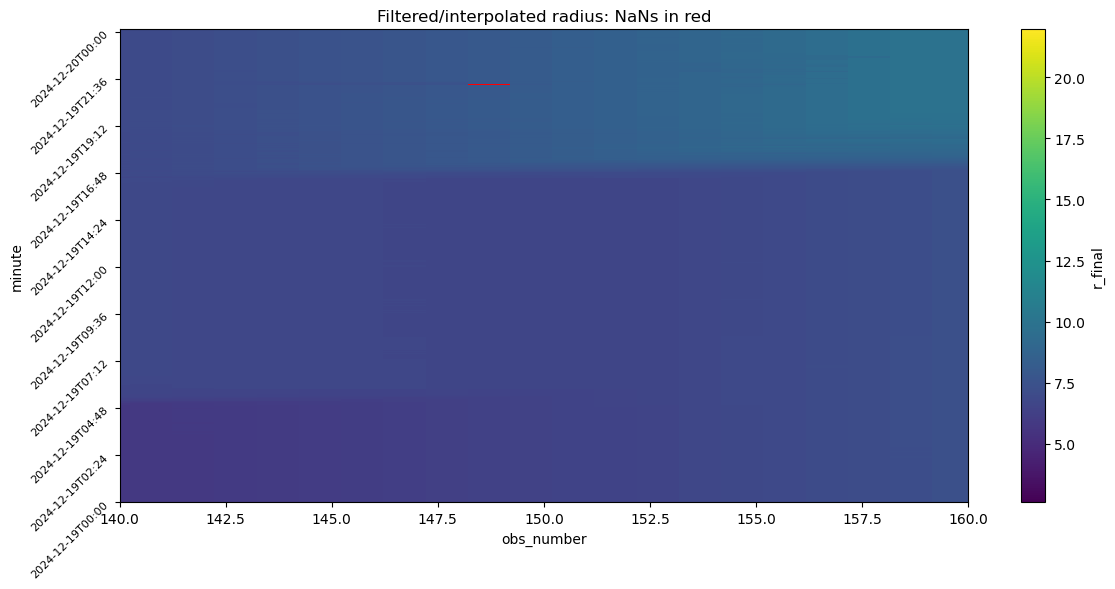

In [148]:
# plot: make an image x=obs_number, y=minute, color=r_final following viridis, with red cells for nans

# Prepare data for plotting
data = r_final.values
obs_numbers = r_final.obs_number.values
minutes = r_final.minute.values

# Create a colormap that shows NaNs as red
cmap = plt.get_cmap('viridis').copy()
cmap.set_bad(color='red')

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(
    data.T,  # transpose so x=obs_number, y=minute
    aspect='auto',
    interpolation='none',
    cmap=cmap,
    origin='lower',
    extent=[obs_numbers[0], obs_numbers[-1], 0, len(minutes)-1]
)

# Set y-ticks to show actual minute labels (optional: show every Nth label for clarity)
yticks = np.arange(0, len(minutes), max(1, len(minutes)//10))
ax.set_yticks(yticks)
ax.set_yticklabels([str(minutes[i])[:16] for i in yticks], rotation=45, fontsize=8)

ax.set_xlabel('obs_number')
ax.set_ylabel('minute')
ax.set_xlim([140, 160])
cbar = plt.colorbar(im, ax=ax, label='r_final')
plt.title('Filtered/interpolated radius: NaNs in red')
plt.tight_layout()
plt.show()

In [100]:
minutes[1200]


np.datetime64('2024-12-19T20:00:00.000000000')

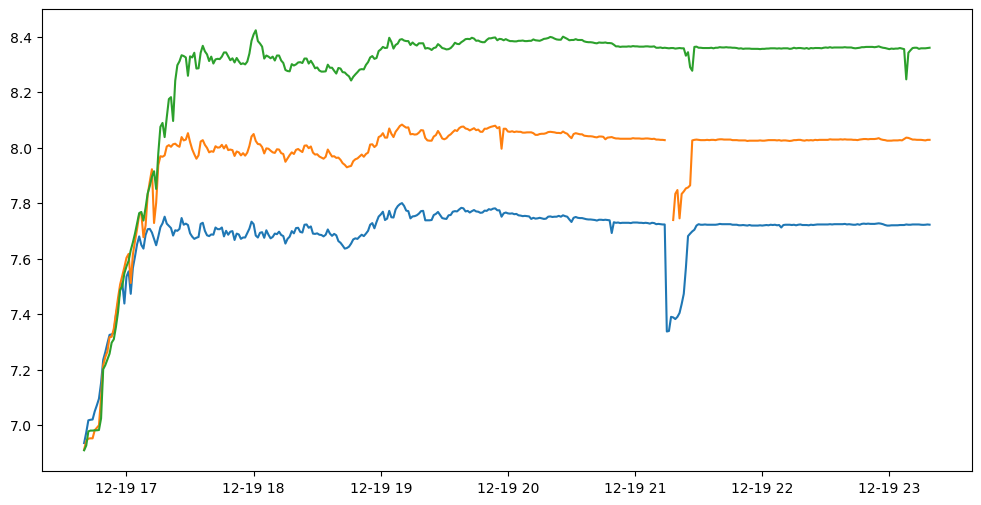

In [150]:
fig, ax = plt.subplots(figsize=(12, 6))
i = 149
ax.plot(minutes[1000:1400], data[i-2,1000:1400])
ax.plot(minutes[1000:1400], data[i,1000:1400])
ax.plot(minutes[1000:1400], data[i+2,1000:1400])

In [136]:
minutes[1195]


np.datetime64('2024-12-19T19:55:00.000000000')

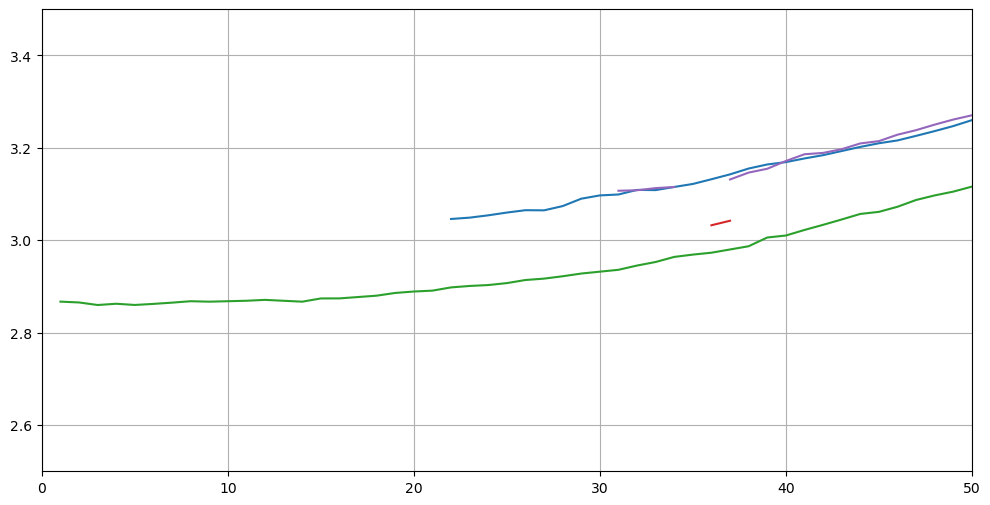

In [135]:
minutes[1190]

fig, ax = plt.subplots(figsize=(12, 6))
t = 1190
i_t = np.arange(t,t+5)
#ax.plot(ds_profiles.x.values[:,i_t], ds_profiles.z.values[:,i_t])
ax.plot(ds_profiles.obs_number, ds_profiles.radius_lidar.values[:,i_t])

# ax.plot(ds_profiles.x.values[:,t], ds_profiles.z.values[:,t+5])
# ax.plot(ds_profiles.x.values[:,t], ds_profiles.z.values[:,t+10])
#ds_profiles
#ax.set_xlim([787, 792])
ax.set_xlim([0, 50])
#ax.set_ylim([1.5, 2])
ax.set_ylim([2.5, 3.5])

ax.grid()

In [52]:
t1 = pd.Timestamp('19-12-2024 21:00') 
t2 = pd.Timestamp('19-12-2024 23:00') 
ds = filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=slice(t1, t2), profile_isel=2) # Filter out frame and high waves (points less than 1 m below lidar and offshore of dune toe)



(1.5, 4.0)

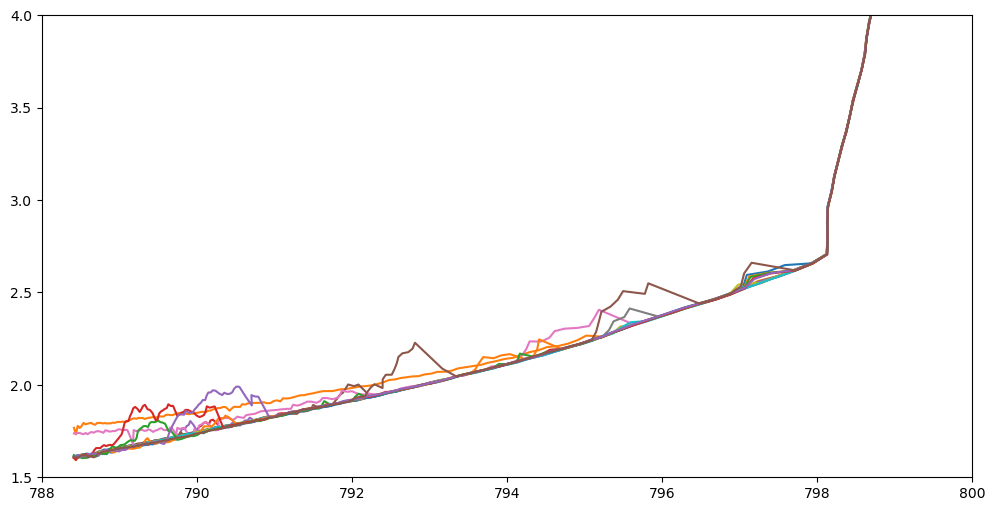

In [95]:
# t1 and t2 as pandas.Timestamp or np.datetime64
# dt_gap as a pandas offset string, e.g. '1min', '30s', '10min'
t1 = pd.Timestamp('2024-12-19 21:00')
t2 = pd.Timestamp('2024-12-19 21:15')
dt_gap = '60s'  # or '15s', '1min', etc.

# Create a time vector with the desired interval
time_vector = pd.date_range(start=t1, end=t2, freq=dt_gap)

# Select the nearest available observation for each desired time
ds_plot = ds.sel(t=time_vector, method='nearest')
ds_plot.t.values

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ds_plot.x.values, ds_plot.z.values, label=ds_plot.t.values)
#ax.legend()
ax.set_xlim([788, 800])
ax.set_ylim([1.5, 4])

In [97]:
# 1. Compute absolute difference over time for each obs_number
dr = np.abs(r.diff(dim='t'))

# 2. Restrict to obs_numbers 125 to 180 (Python is 0-based, so 125:181)
dr_sel = dr.sel(obs_number=slice(0, 125))

# 3. Sum over obs_number for each time step (result: time series)
dr_sum = dr_sel.sum(dim='obs_number')

# 4. Assign minute labels (skip first time step due to diff)
minute_labels = pd.to_datetime(dr_sum.t.values).floor('min')
dr_sum = dr_sum.assign_coords(minute=('t', minute_labels))

# 5. Group by minute and compute 99th percentile of summed changes
def nanpercentile_99_xr(x):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN slice encountered")
        val = np.nanpercentile(x.values, 99)
    # Return as 0D DataArray with minute as a coordinate
    return xr.DataArray(val, coords={'minute': x.minute.values[0]})

dr_99 = dr_sum.groupby('minute').apply(nanpercentile_99_xr)

# dr_99 is now a time series: 99th percentile of summed profile change per minute

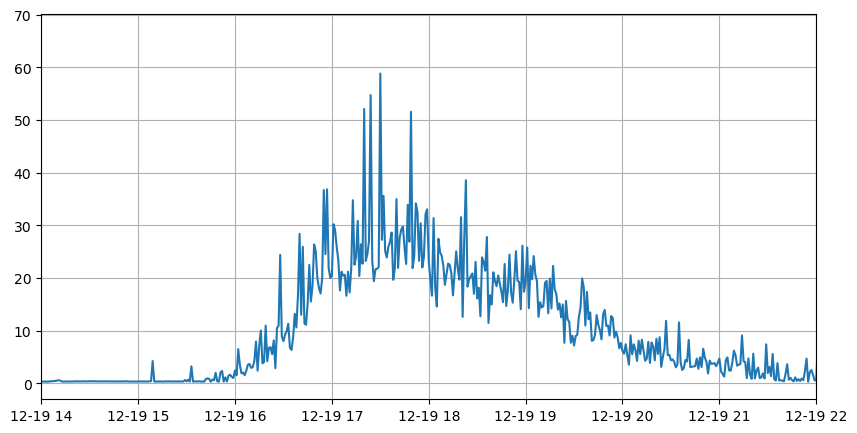

In [98]:
# plot dr_99
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dr_99.minute.values, dr_99.values)
ax.set_xlim(pd.Timestamp('2024-12-19 14:00'), pd.Timestamp('2024-12-19 22:00'))
ax.grid()

In [ ]:
# DUNE VOLUME EXTRACTION
n_lidar = 2  # set as needed (1-based, like MATLAB)
for n_storm in [1, 2, 3]:
    ds_plot = invert ds123a
# CALCULATE DUNE VOLUME: THE VOLUME UNDER THE PROFILE-------------------------------------------------------------------
    # calculate area using shoelace formula
    def polygon_area(x, z):
        return 0.5 * np.abs(np.dot(x, np.roll(z, 1)) - np.dot(z, np.roll(x, 1)))

    # Loop over all t and calculate dune volume for each profile.           V1: x>793--------------------------------------
    volumes = []
    for n_t in range(ds_plot.x.shape[1]):
        x = ds_plot.x[:, n_t].values
        z = ds_plot.z[:, n_t].values

        # filter: select only non-nan x
        mask = ~np.isnan(x)
        x = x[mask]
        z = z[mask]

        # select x, z where x>793 and x<802
        i = (x > 793) & (x < 802)
        x = x[i]
        z = z[i]

        if len(x) == 0:
            volumes.append(np.nan)
            continue
        if (n_storm == 1) & (n_lidar==2):
            x = np.concatenate(( x, [x[-1]+0.3] ))
            z = np.concatenate(( z, [4.79] ))
        elif (n_storm==3) & (n_lidar==2):
            x = np.concatenate((x, [max(800.45, x[-1] + 0.15)]))
            z = np.concatenate((z, [4.85]))
        elif (n_storm==3) & (n_lidar==1):
            x = np.concatenate((x, [min(800.45, x[-1] + 0.47)]))
            z = np.concatenate((z, [4.79]))
                        
        # pad: make a triangle
        x = np.concatenate(([793, 793], x, [802, 802, 793]))
        z = np.concatenate(([1.5, z[0]], z, [z[-1], 1.5, 1.5]))

        # Calculate dune volume
        area = polygon_area(x, z)
        volumes.append(area)

    # Calculate erosion_volume: 0 for t=0, then difference in volume for all subsequent steps
    volumes = np.array(volumes)
    erosion_volume = np.zeros_like(volumes)
    erosion_volume[:-1] = volumes[:-1] - volumes[1:] # erosion at time t is V(t) - V(t+1). Or -E = dV = V(t+1)-V(t)

    # Assign erosion_volume to ds for every t, with attribute 'Units' = 'm3/m'
    ds_plot['erosion_volume1'] = (('t',), erosion_volume)
    ds_plot['erosion_volume1'].attrs['Units'] = 'm3/m'

    # Loop over all t and calculate dune volume for each profile.           V2: z>2---------------------------------------
    volumes = []
    for n_t in range(ds_plot.x.shape[1]):
        x = ds_plot.x[:, n_t].values
        z = ds_plot.z[:, n_t].values

        # filter: select only non-nan x
        mask = ~np.isnan(x)
        x = x[mask]
        z = z[mask]

        # select x, z where x>793 and x<802
        i = (z > 2) & (x < 802)
        x = x[i]
        z = z[i]

        if len(x) == 0:
            volumes.append(np.nan)
            continue
        if (n_storm == 1) & (n_lidar==2):
            x = np.concatenate(( x, [x[-1]+0.3] ))
            z = np.concatenate(( z, [4.79] ))
        elif (n_storm==3) & (n_lidar==2):
            x = np.concatenate((x, [min(800.45, x[-1] + 0.15)]))
            z = np.concatenate((z, [4.85]))
        elif (n_storm==3) & (n_lidar==1):
            x = np.concatenate((x, [min(800.45, x[-1] + 0.47)]))
            z = np.concatenate((z, [4.79]))
            
        # pad: make a triangle
        x = np.concatenate(( [x[0]], x, [802,   802, x[0]] ))
        z = np.concatenate(( [2],    z, [z[-1], 2,   2   ] ))

        # Calculate dune volume
        area = polygon_area(x, z)
        volumes.append(area)

    # Calculate erosion_volume: 0 for t=0, then difference in volume for all subsequent steps
    volumes = np.array(volumes)
    erosion_volume = np.zeros_like(volumes)
    erosion_volume[:-1] = volumes[:-1] - volumes[1:]

    # Assign erosion_volume to ds for every t, with attribute 'Units' = 'm3/m'
    ds_plot['dune_volume'] = (('t',), volumes)
    ds_plot['dune_volume'].attrs['Units'] = 'm3/m'
    ds_plot['erosion_volume2'] = (('t',), erosion_volume)
    ds_plot['erosion_volume2'].attrs['Units'] = 'm3/m'
    print("Erosion volumes assigned to ds['erosion_volume'].")